# Unsupervised Learning on Country Data

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Exploratory Data Analysis

In [2]:
df = pd.read_csv("data/data.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


In [3]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [4]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [5]:
def plot_distributions(df_num, savepath=None):
    """Plots histogram with density line in a 3x3 grid."""
    fig, axes = plt.subplots(3, 3, figsize=(14, 14))
    axes = axes.flatten()
    
    for i, col in enumerate(df_num.columns):
        sns.histplot(df_num[col], kde=True, ax=axes[i], color='skyblue')

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()

def plot_correlations(df, savepath=None): 
    """Calculates and plots a heatmap of the Pearson correlation matrix."""
    df_num = df.select_dtypes(include=[np.number])
    corr_matrix = df_num.corr()
    
    plt.figure(figsize=(9.5, 9))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))    
    sns.heatmap(corr_matrix, mask=mask, 
                annot=True, fmt=".2f", 
                square=True, 
                linewidths=0.5,
                annot_kws={"size": 10, "weight": "bold"},
                cmap="vlag", cbar=None)
    
    plt.xticks(fontsize=9, rotation=45, ha='right')
    plt.yticks(fontsize=9, rotation=0)
    plt.xlabel("")
    plt.ylabel("")
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()

def plot_scatter(df, savepath=None): 
    """Plots pairwise scatter plots for numerical columns against each other dynamically."""
    df_num = df.select_dtypes(include=[np.number])
    cols = df_num.columns
    n = len(cols)
    
    # Generate an appropriate grid size dynamically based on column count
    fig, axes = plt.subplots(n, n, figsize=(4 * n, 4 * n))
    
    # Handle case where there is only 1 numeric column
    if n == 1:
        axes = np.array([[axes]])
        
    for i in range(n):
        for j in range(n):
            ax = axes[i, j]
            if i == j:
                # Diagonal: Show the distribution of that single variable
                sns.histplot(df_num[cols[i]], kde=True, ax=ax, color='skyblue')
            else:
                # Off-diagonal: Show relationship between two variables
                sns.scatterplot(x=df_num[cols[j]], y=df_num[cols[i]], ax=ax, color='salmon', alpha=0.6)
            
            # Clean up labels so it looks like a clean pairplot matrix
            if i == n - 1: ax.set_xlabel(cols[j])
            else: ax.set_xlabel('')
            if j == 0: ax.set_ylabel(cols[i])
            else: ax.set_ylabel('')

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()

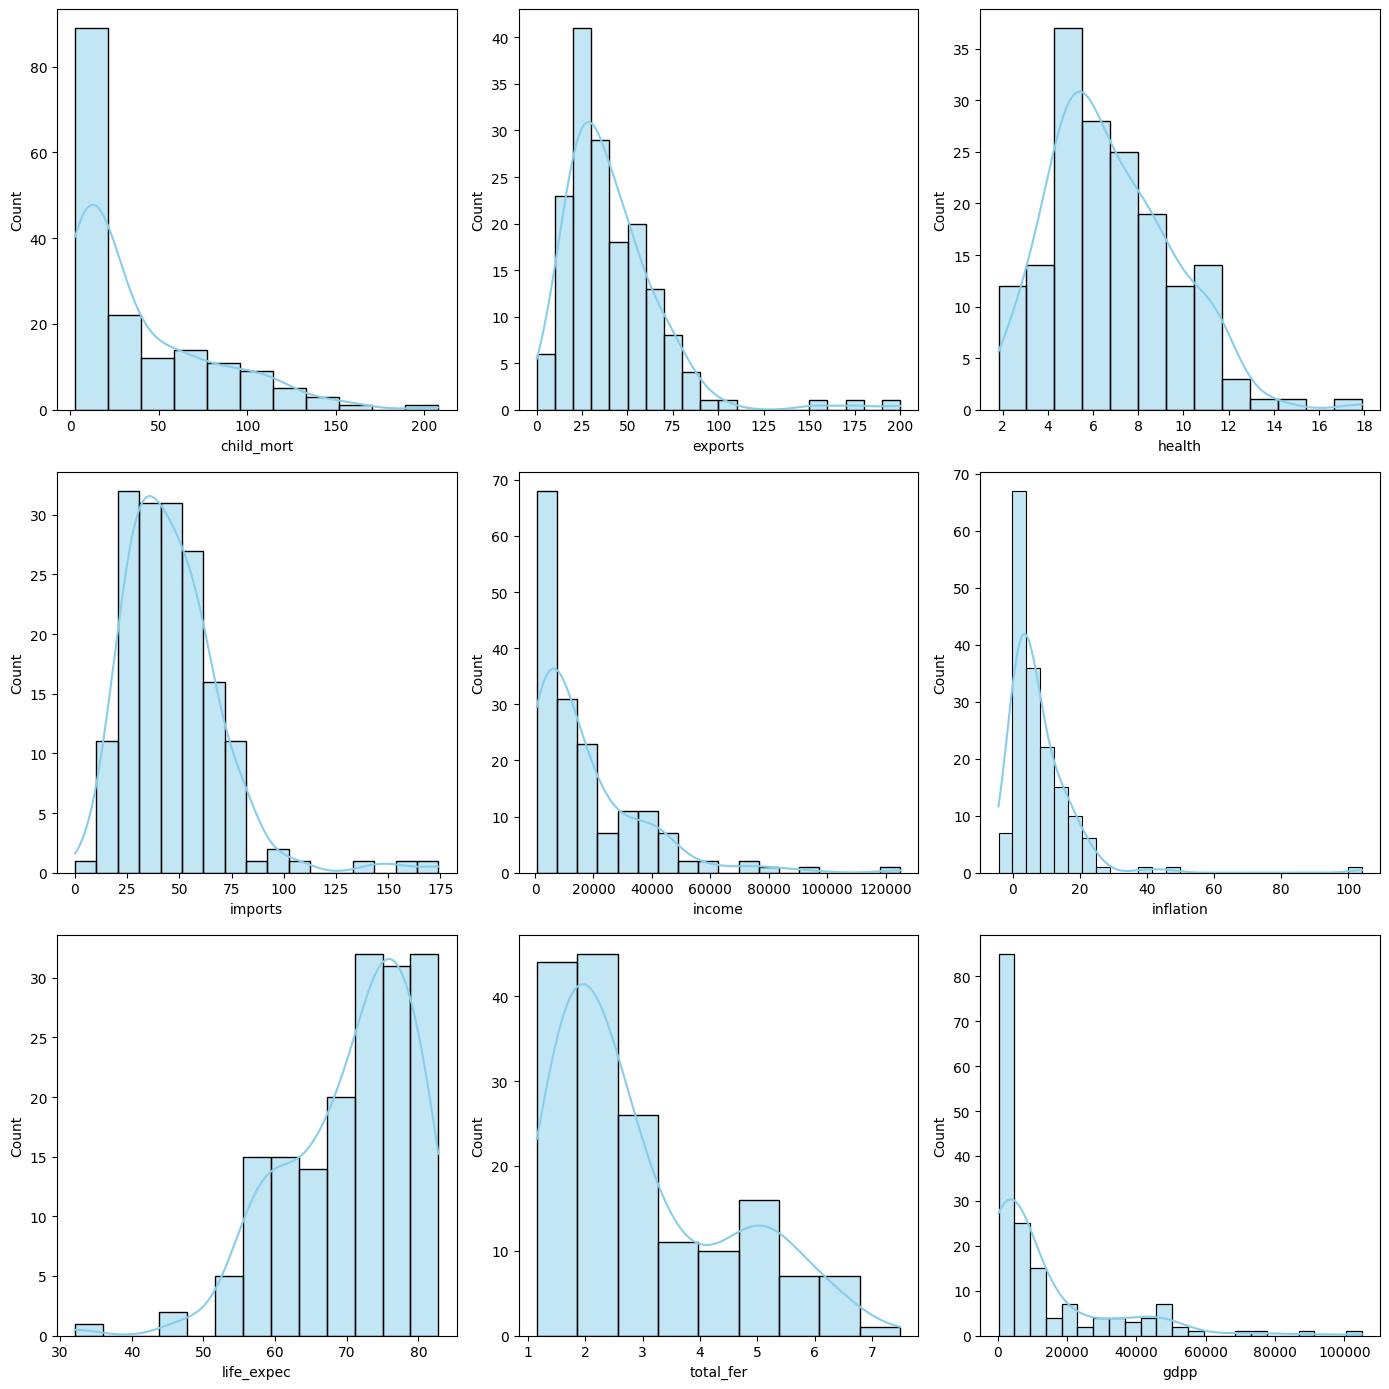

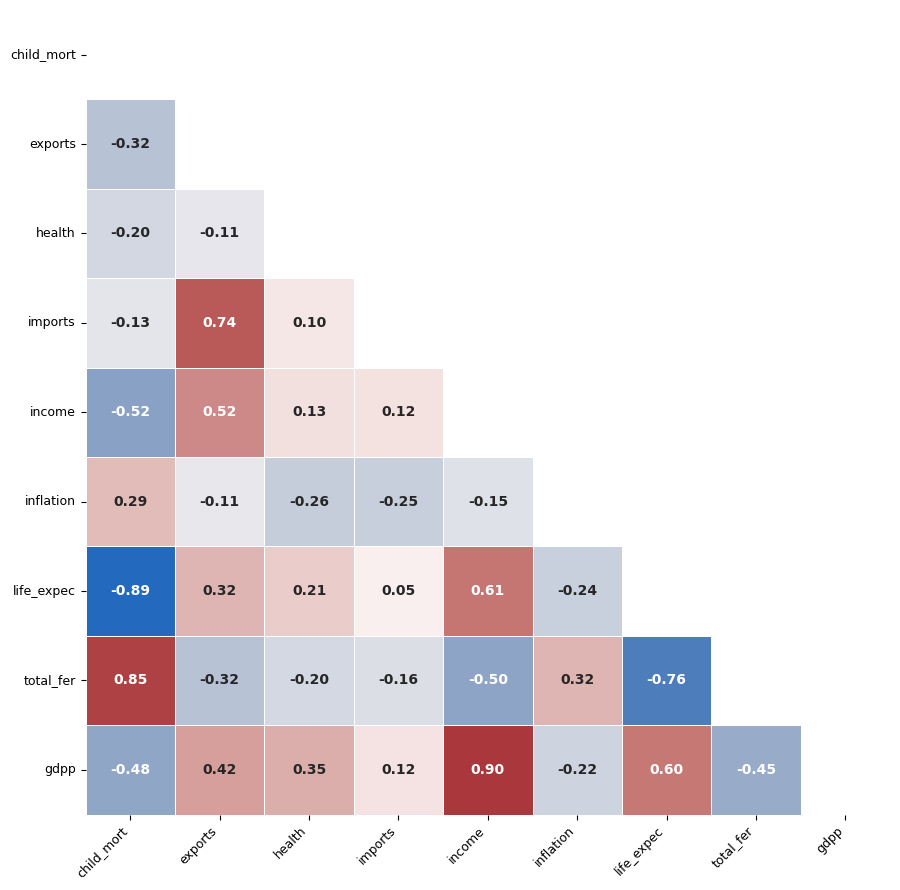

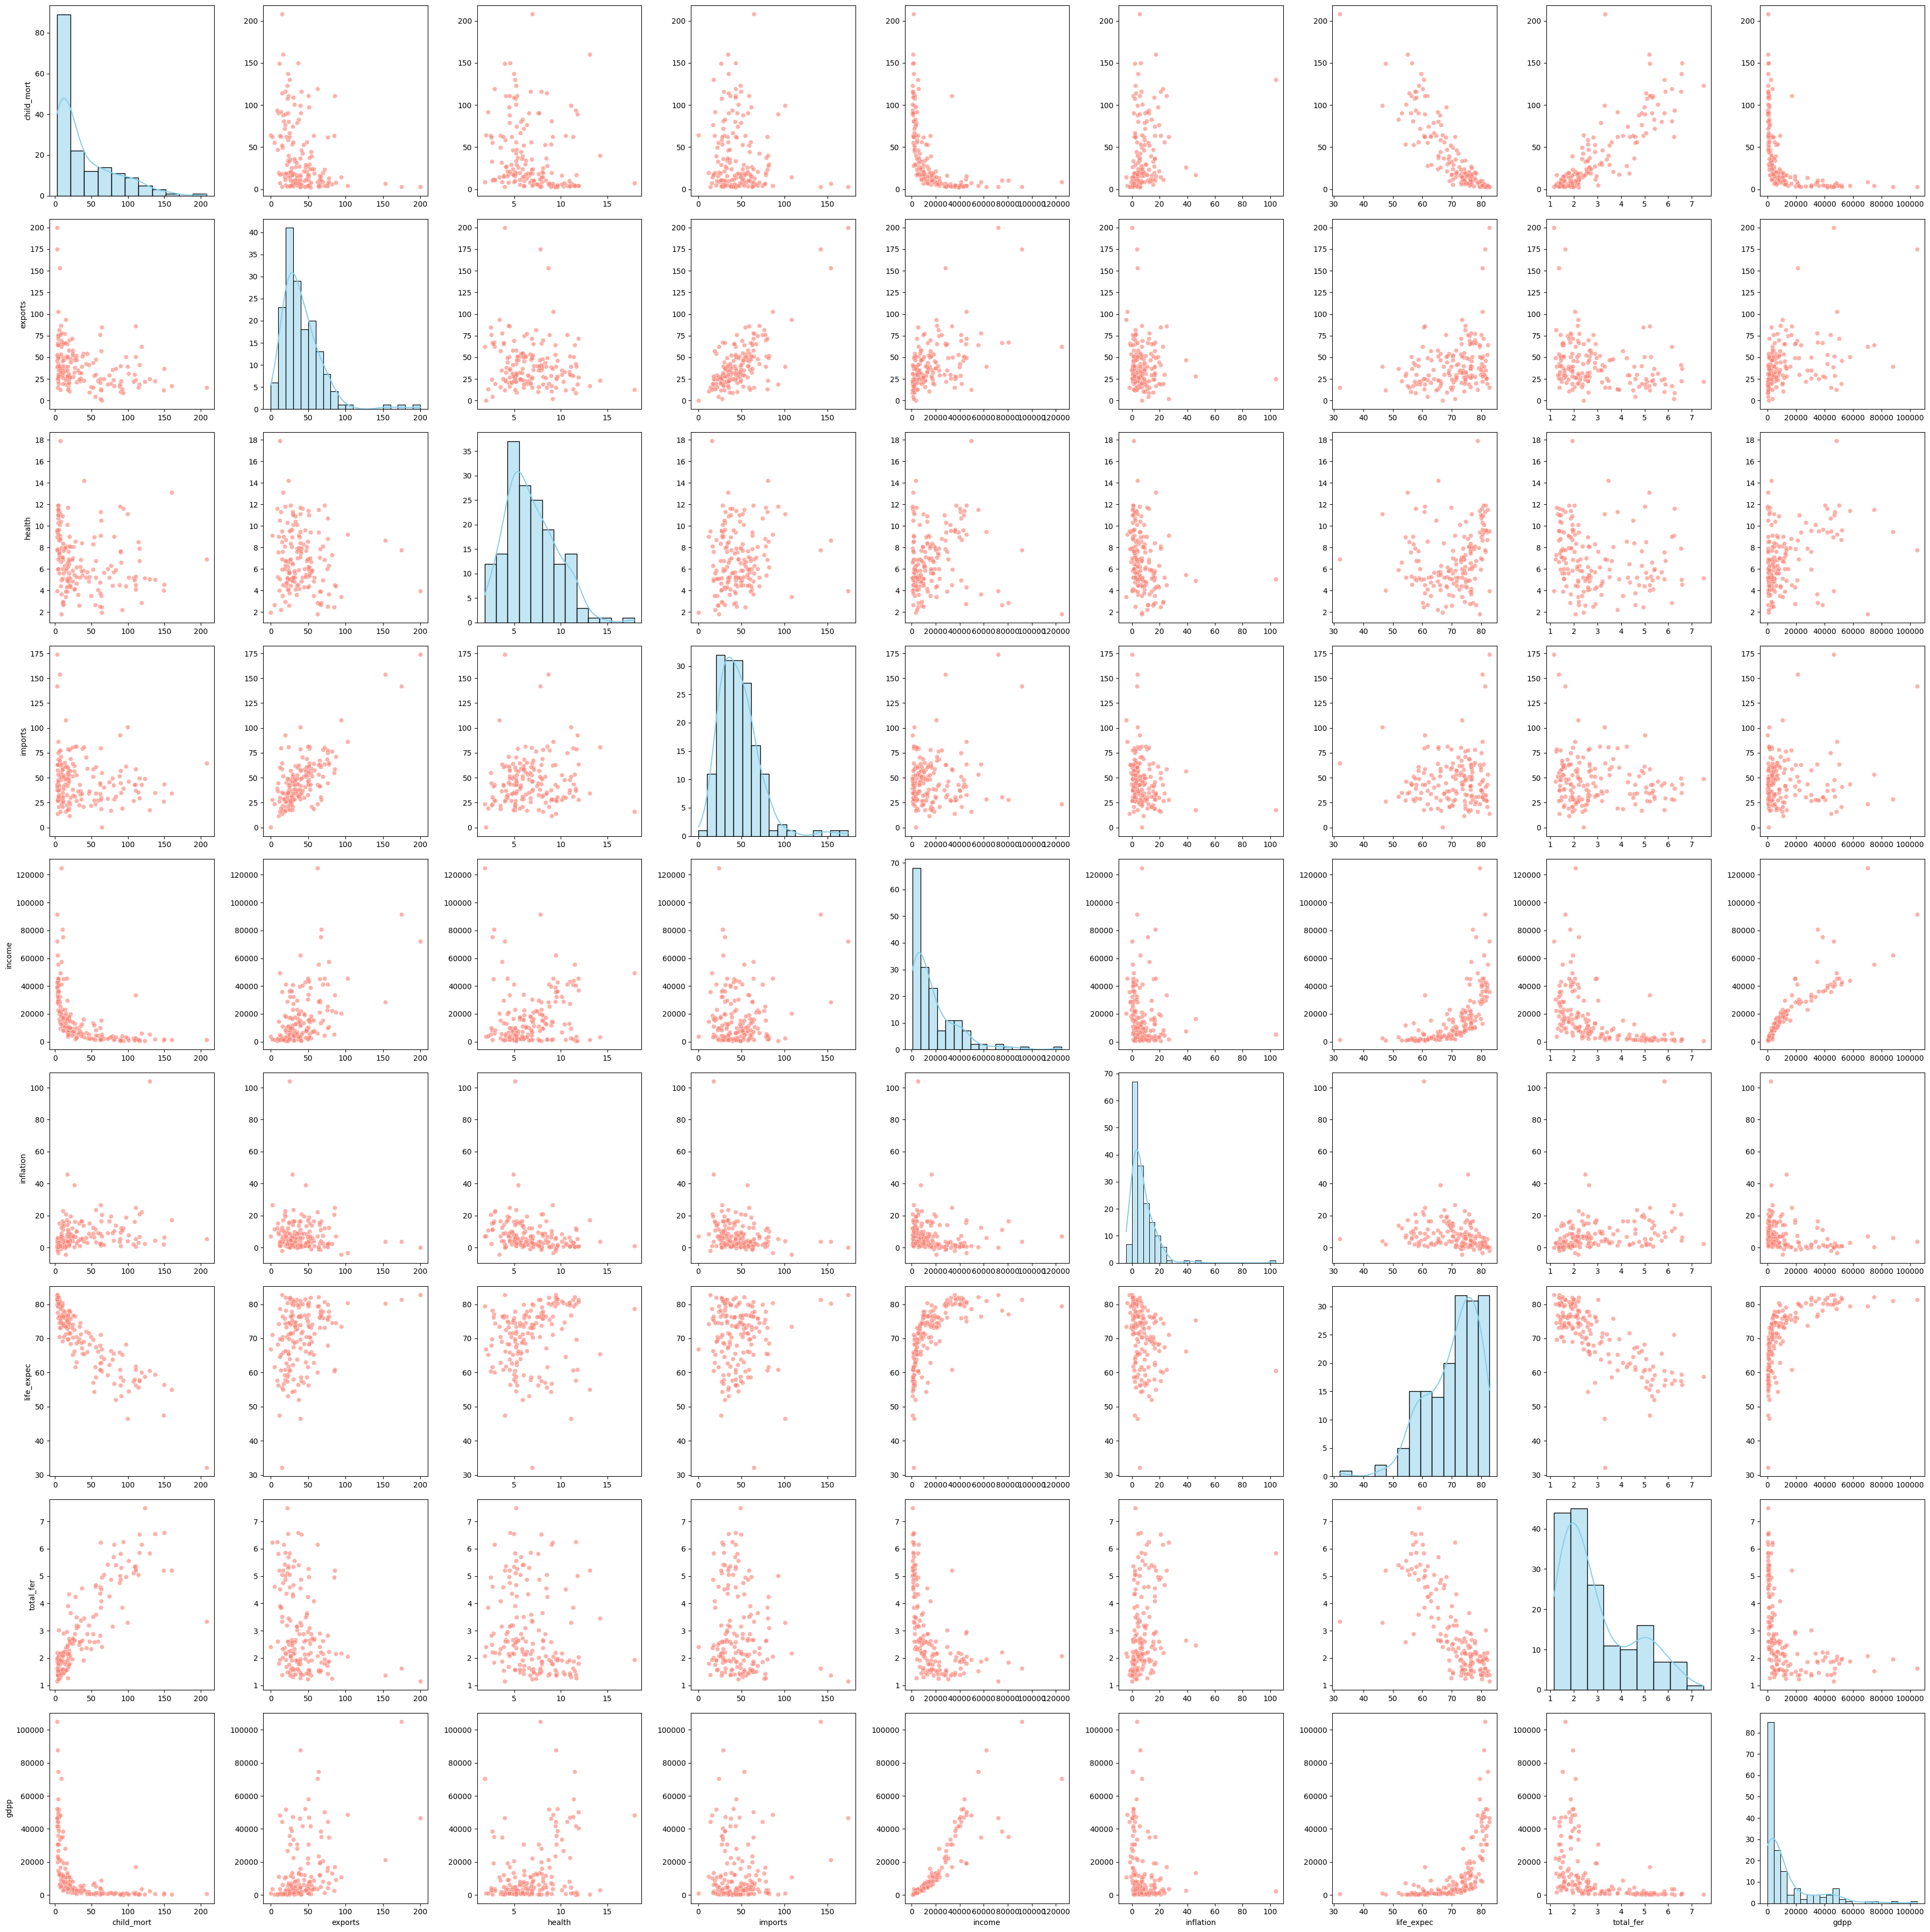

In [6]:
df_num = df.drop('country', axis=1)
plot_distributions(df_num, "images/distributions.png")
plot_correlations(df_num, "images/correlations.png")
plot_scatter(df_num, "images/scatter.png")

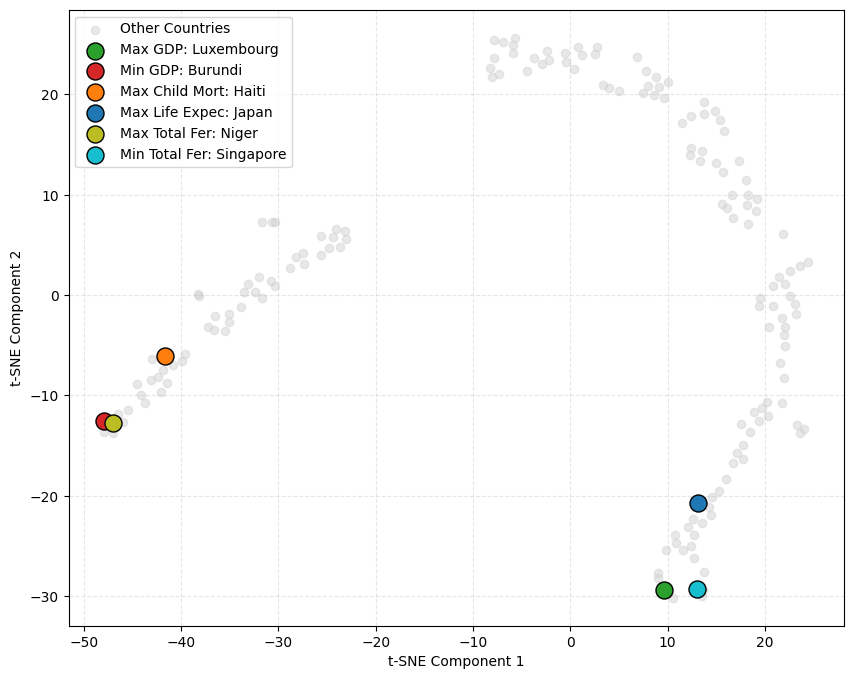

In [7]:
from sklearn.manifold import TSNE

def plot_tsne(df, perplexity=10, savepath=None):
    df_num = df.select_dtypes(include=[np.number])
    tsne = TSNE(n_components=2, perplexity=perplexity, max_iter=2500, random_state=42)
    tsne_results = tsne.fit_transform(df_num)
    
    # Identify specific interesting points
    idx_max_gdp = df['gdpp'].idxmax()
    idx_min_gdp = df['gdpp'].idxmin()
    idx_max_mort = df['child_mort'].idxmax()
    idx_max_life_exp = df['life_expec'].idxmax()
    idx_max_total_fer = df['total_fer'].idxmax()
    idx_min_total_fer = df['total_fer'].idxmin()
    
    highlight_indices = [idx_max_gdp, idx_min_gdp, idx_max_mort, idx_max_life_exp, idx_max_total_fer, idx_min_total_fer]
    highlight_colors = ['tab:green', 'tab:red', 'tab:orange', 'tab:blue', 'tab:olive', 'tab:cyan']

    # tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan
    highlight_names = [f"Max GDP: {df.loc[idx_max_gdp, 'country']}", 
                       f"Min GDP: {df.loc[idx_min_gdp, 'country']}",
                       f"Max Child Mort: {df.loc[idx_max_mort, 'country']}",
                       f"Max Life Expec: {df.loc[idx_max_life_exp, 'country']}", 
                       f"Max Total Fer: {df.loc[idx_max_total_fer, 'country']}", 
                       f"Min Total Fer: {df.loc[idx_min_total_fer, 'country']}", 
                       ]


    """Plots the 2D t-SNE projection highlighting specific data points."""
    plt.figure(figsize=(10, 8))
    
    plt.scatter(tsne_results[:, 0], tsne_results[:, 1], color='lightgray', alpha=0.5, label='Other Countries')
    for idx, color, name in zip(highlight_indices, highlight_colors, highlight_names):
        plt.scatter(tsne_results[idx, 0], tsne_results[idx, 1], 
                    color=color, s=150, edgecolors='black', label=name, zorder=5)
        
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.3)
    if savepath: 
        plt.savefig(savepath, bbox_inches='tight')
    plt.show()

plot_tsne(df, savepath="images/tsne.png")

Perplexity = 2


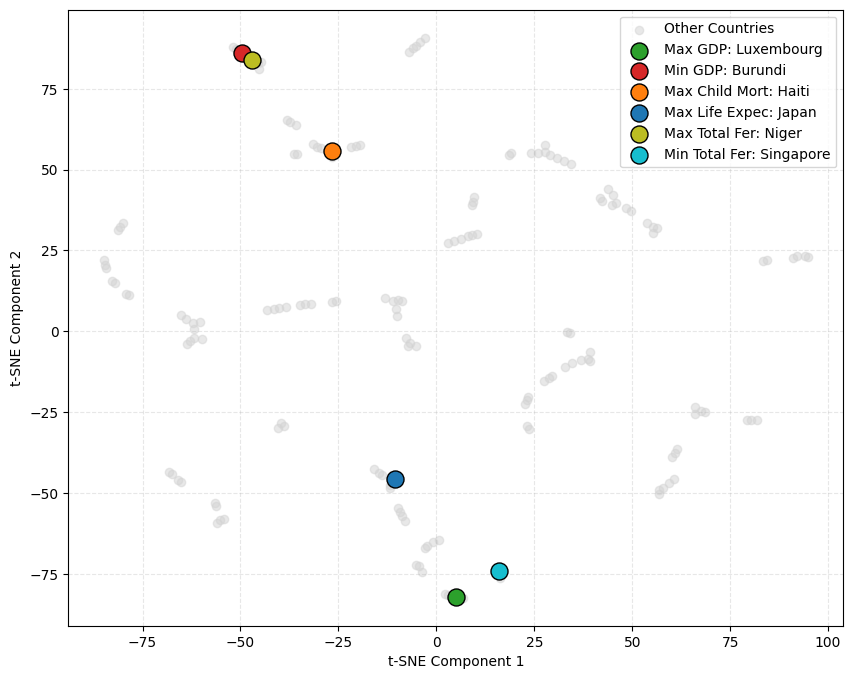

Perplexity = 5


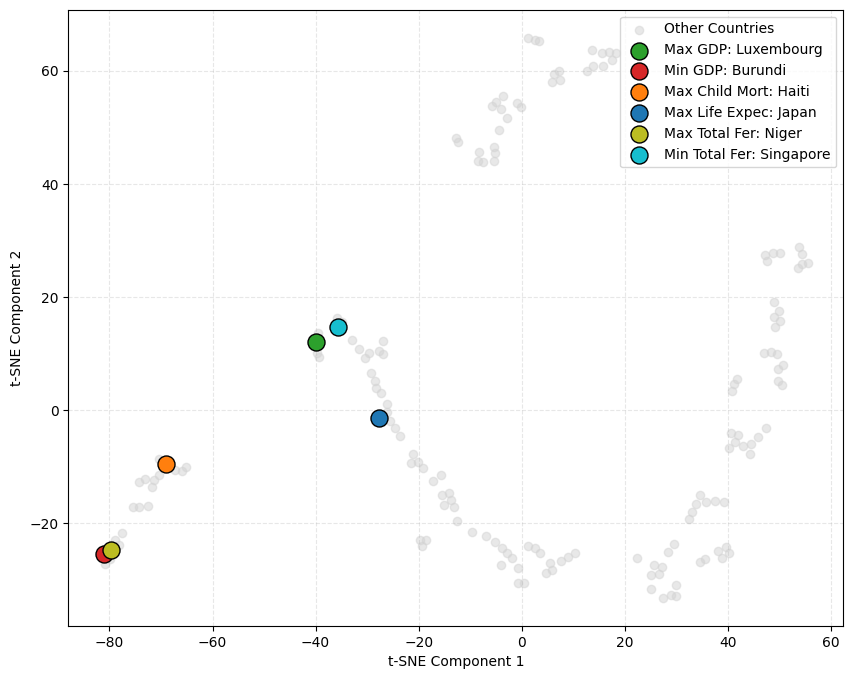

Perplexity = 10


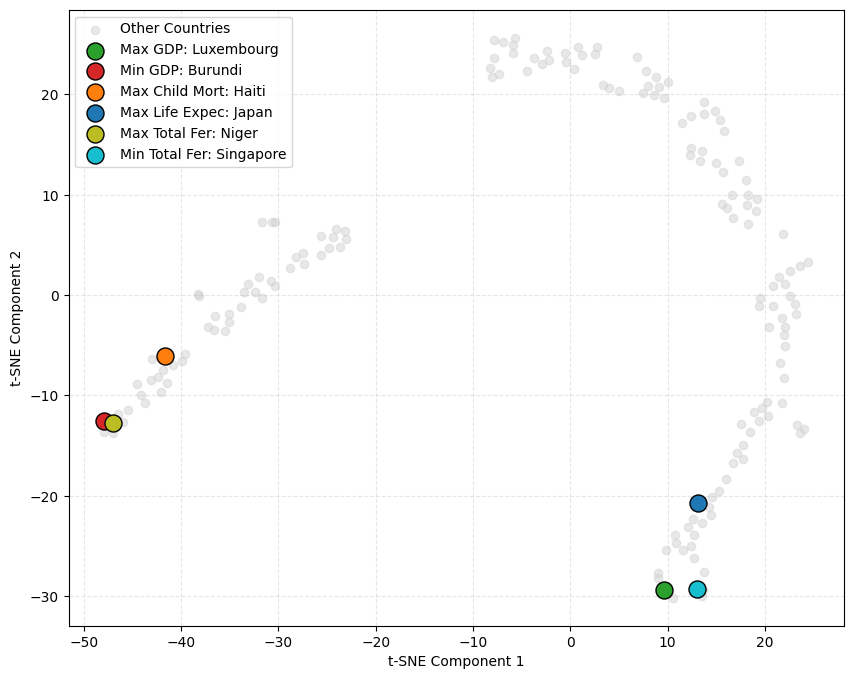

Perplexity = 15


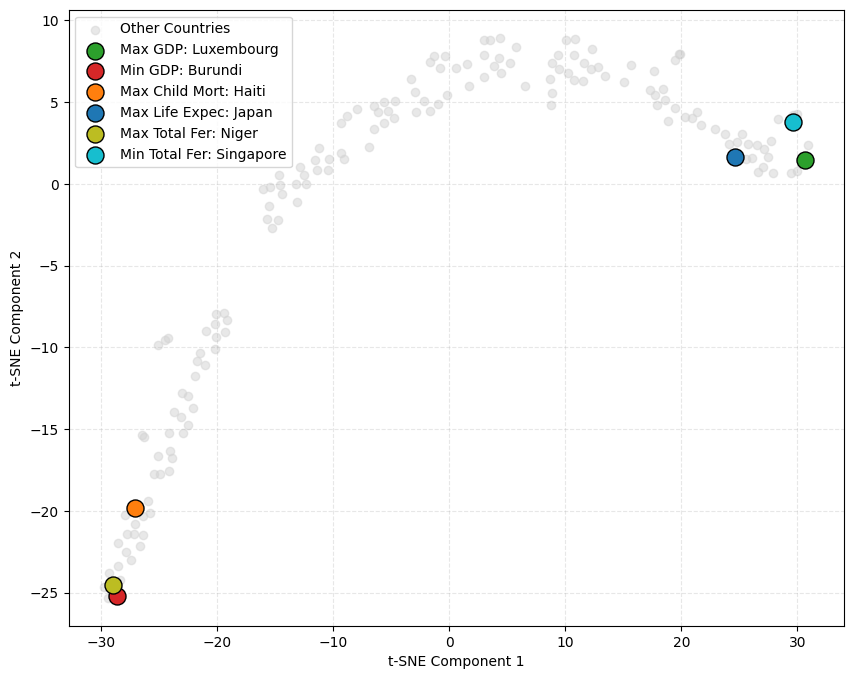

Perplexity = 30


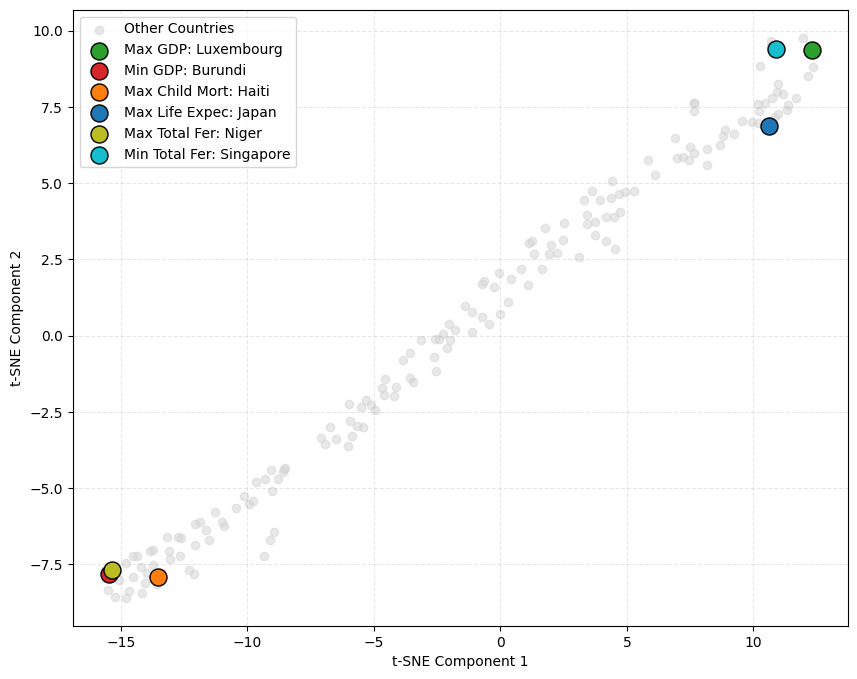

Perplexity = 50


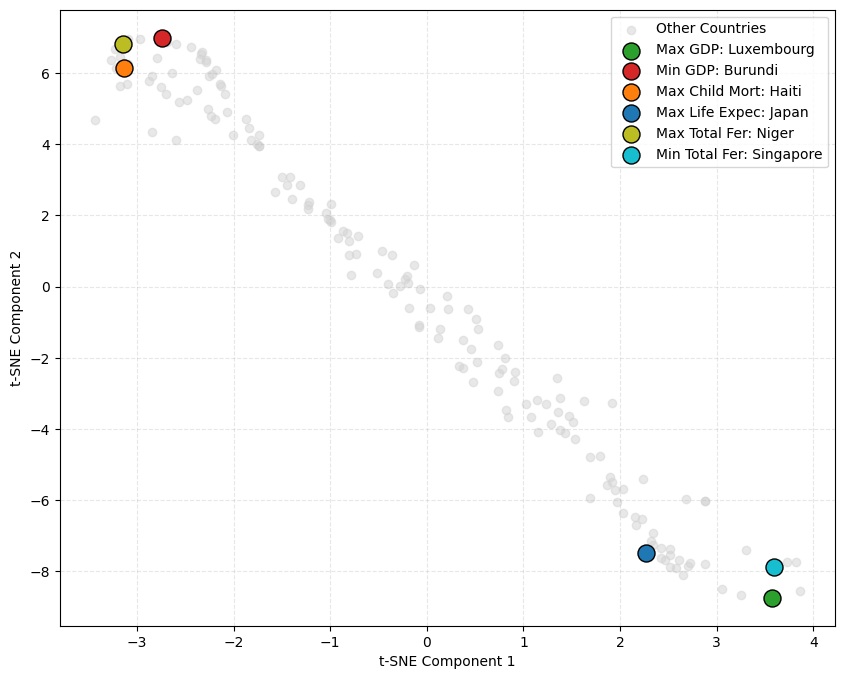

In [8]:
for perplexity in [2, 5, 10, 15, 30, 50]: 
    print(f"Perplexity = {perplexity}")
    plot_tsne(df, perplexity=perplexity)

In [9]:
from sklearn.preprocessing import StandardScaler, PowerTransformer

ss = StandardScaler()
X_std = ss.fit_transform(df_num)
df_std = pd.DataFrame(X_std, columns=df_num.columns)

pt = PowerTransformer()
X_pwr = pt.fit_transform(df_num)
df_pwr = pd.DataFrame(X_pwr, columns=df_num.columns)

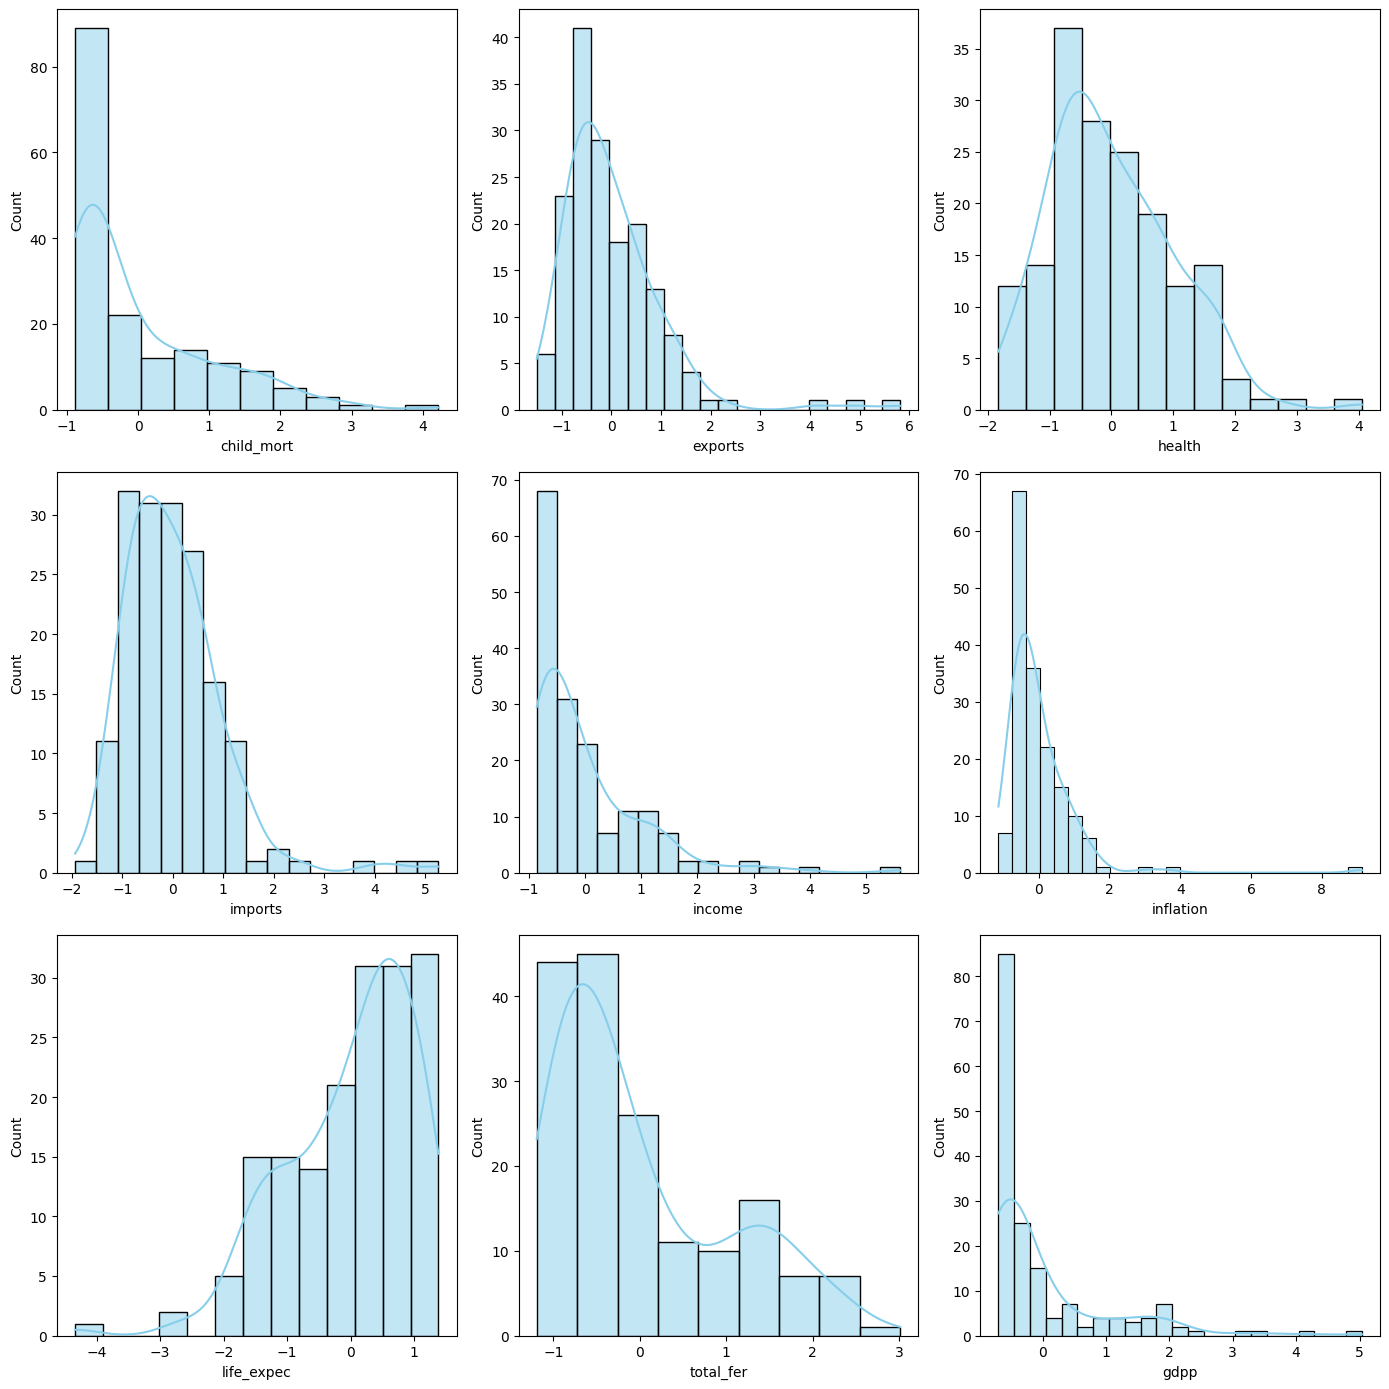

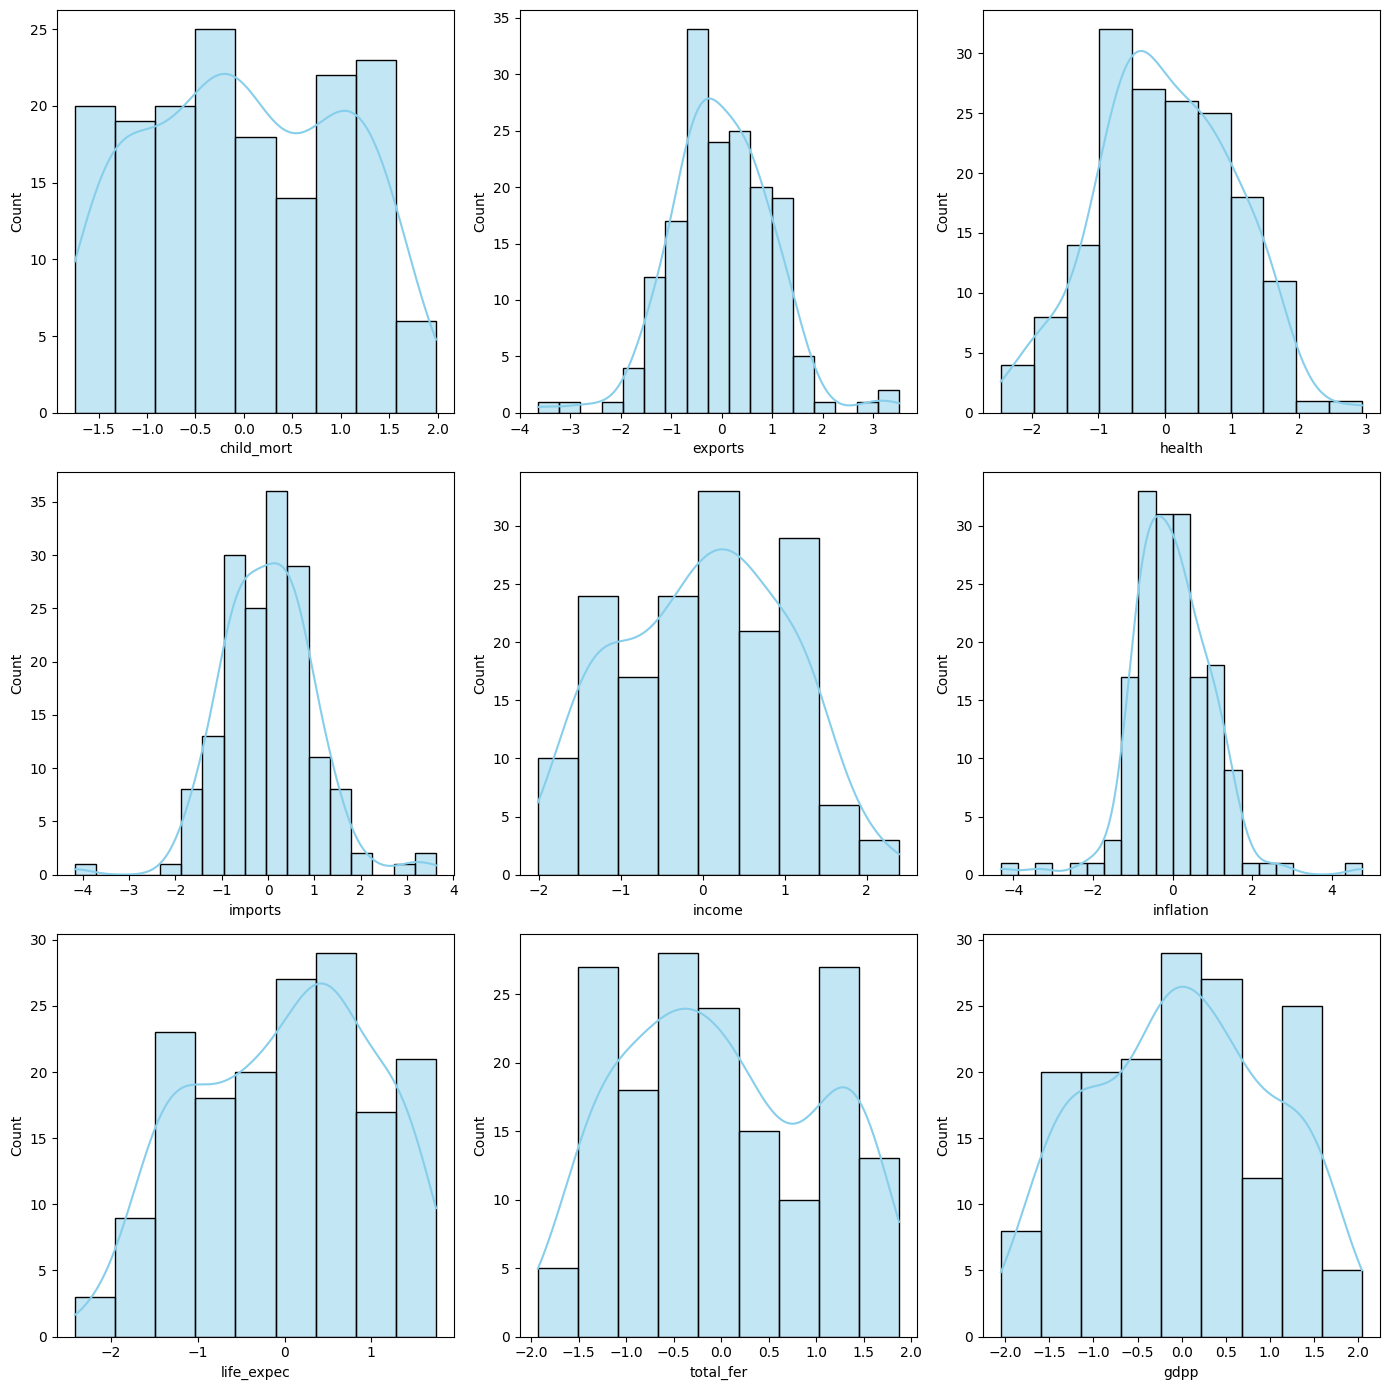

In [10]:
plot_distributions(df_std, "images/distributions_std.png")
plot_distributions(df_pwr, "images/distributions_pwr.png")

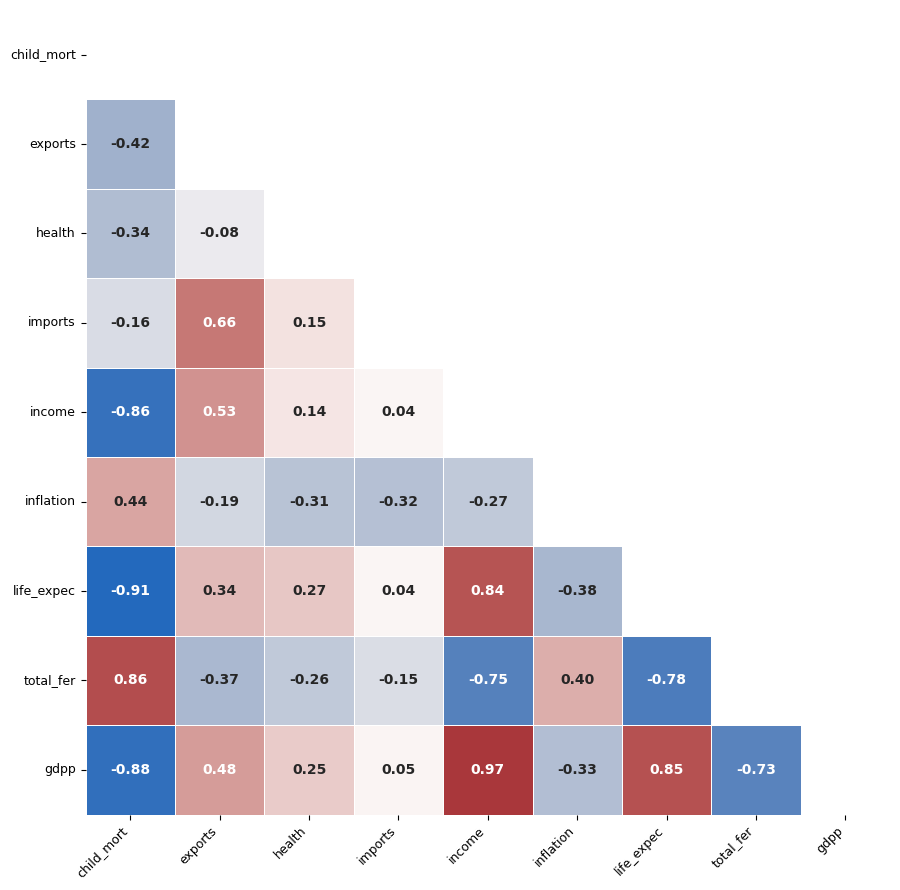

In [11]:
plot_correlations(df_pwr, "images/correlations_pwr.png")

In [21]:
palette = {'Standard Scaling': '#8cd98c', 'Power Transform': '#4da6ff'}

def plot_compared_distributions(combined_df, savepath=None):
    """Refined 3x3 distribution grid with optimized margins and label reduction."""    
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.flatten()
    
    features = [col for col in combined_df.columns if col != 'Strategy']

    for i, col in enumerate(features):
        ax = axes[i]
        sns.kdeplot(ax=ax, data=combined_df, x=col, 
                    hue='Strategy', palette=palette, fill=True, alpha=0.15)
        
        ax.set_title(f'{col}', fontsize=13, fontweight='bold', pad=8)
        
        ax.locator_params(axis='x', nbins=4) 
        ax.tick_params(labelsize=9)

        ax.set_xlabel('Scaled Value' if i >= 6 else '', fontsize=10)
        ax.set_ylabel('Density' if i % 3 == 0 else '', fontsize=10)
        
        ax.get_legend().remove()
        ax.grid(True, linestyle='--', alpha=0.3, axis='both')
        sns.despine(ax=ax)
    
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()


def plot_compared_boxplots(combined_df, savepath=None):
    """Refined 3x3 boxplot grid configured to visually mirror the distribution grid."""
    features = [col for col in combined_df.columns if col != 'Strategy']
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.flatten()
    
    for i, col in enumerate(features):
        ax = axes[i]
        sns.boxplot(ax=ax, data=combined_df, x='Strategy', y=col,
                    hue='Strategy', palette=palette, width=0.5, legend=False)
        
        ax.set_title(f'{col}', fontsize=13, fontweight='bold', pad=8)
        
        ax.set_ylabel('Scaled Value' if i % 3 == 0 else '', fontsize=10)
        
        ax.set_xlabel('')
        ax.set_xticklabels([]) 
        ax.tick_params(labelsize=9)
        
        ax.grid(True, linestyle='--', alpha=0.3, axis='y')
        sns.despine(ax=ax)
        
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()

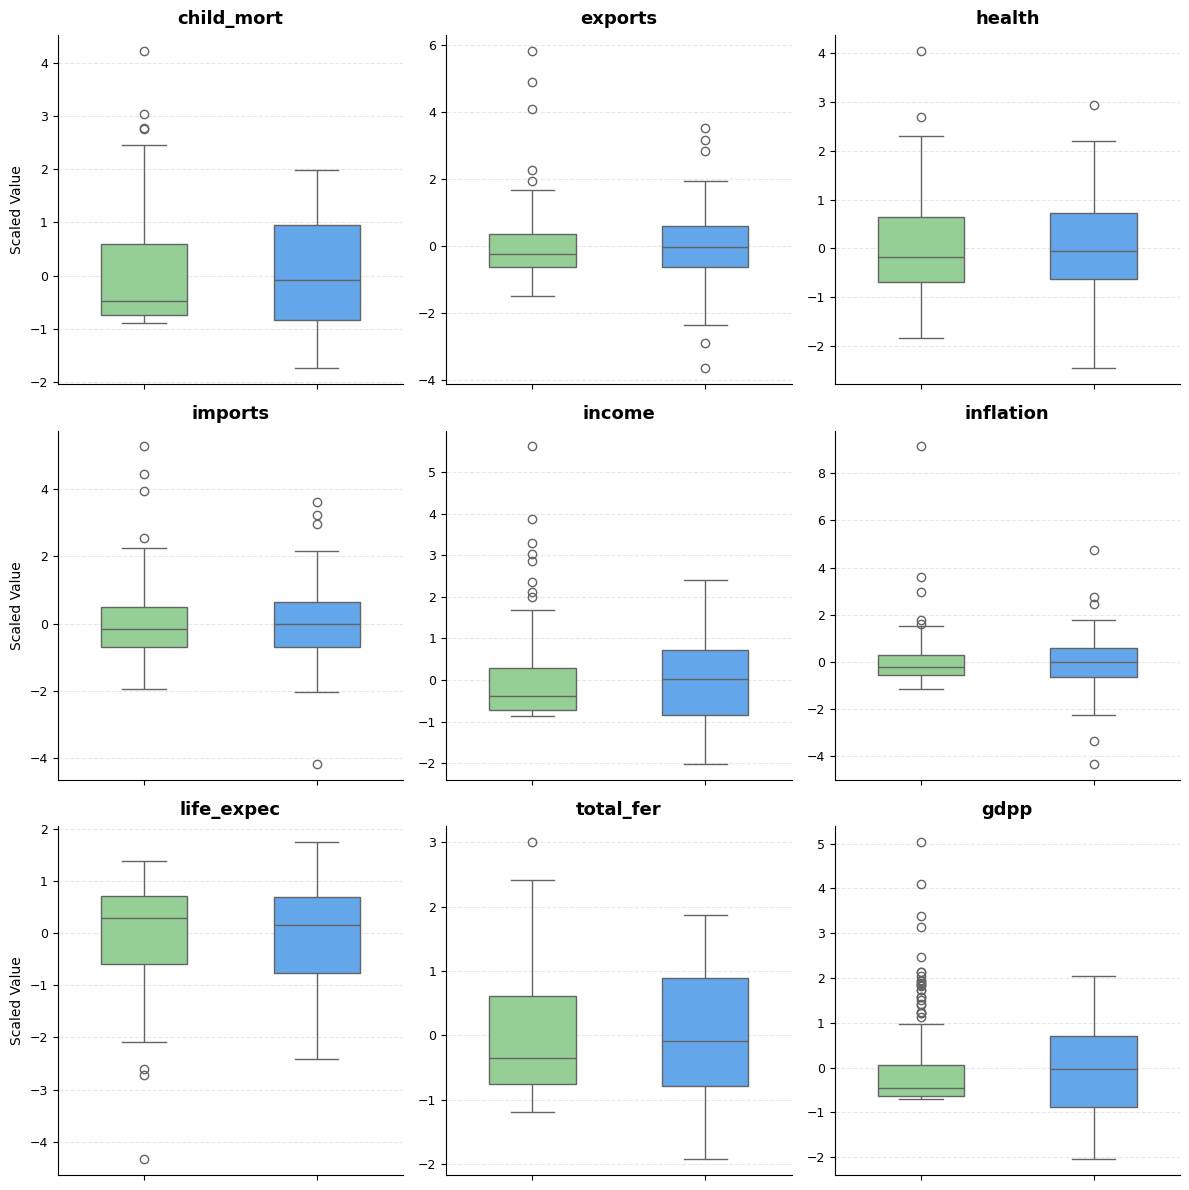

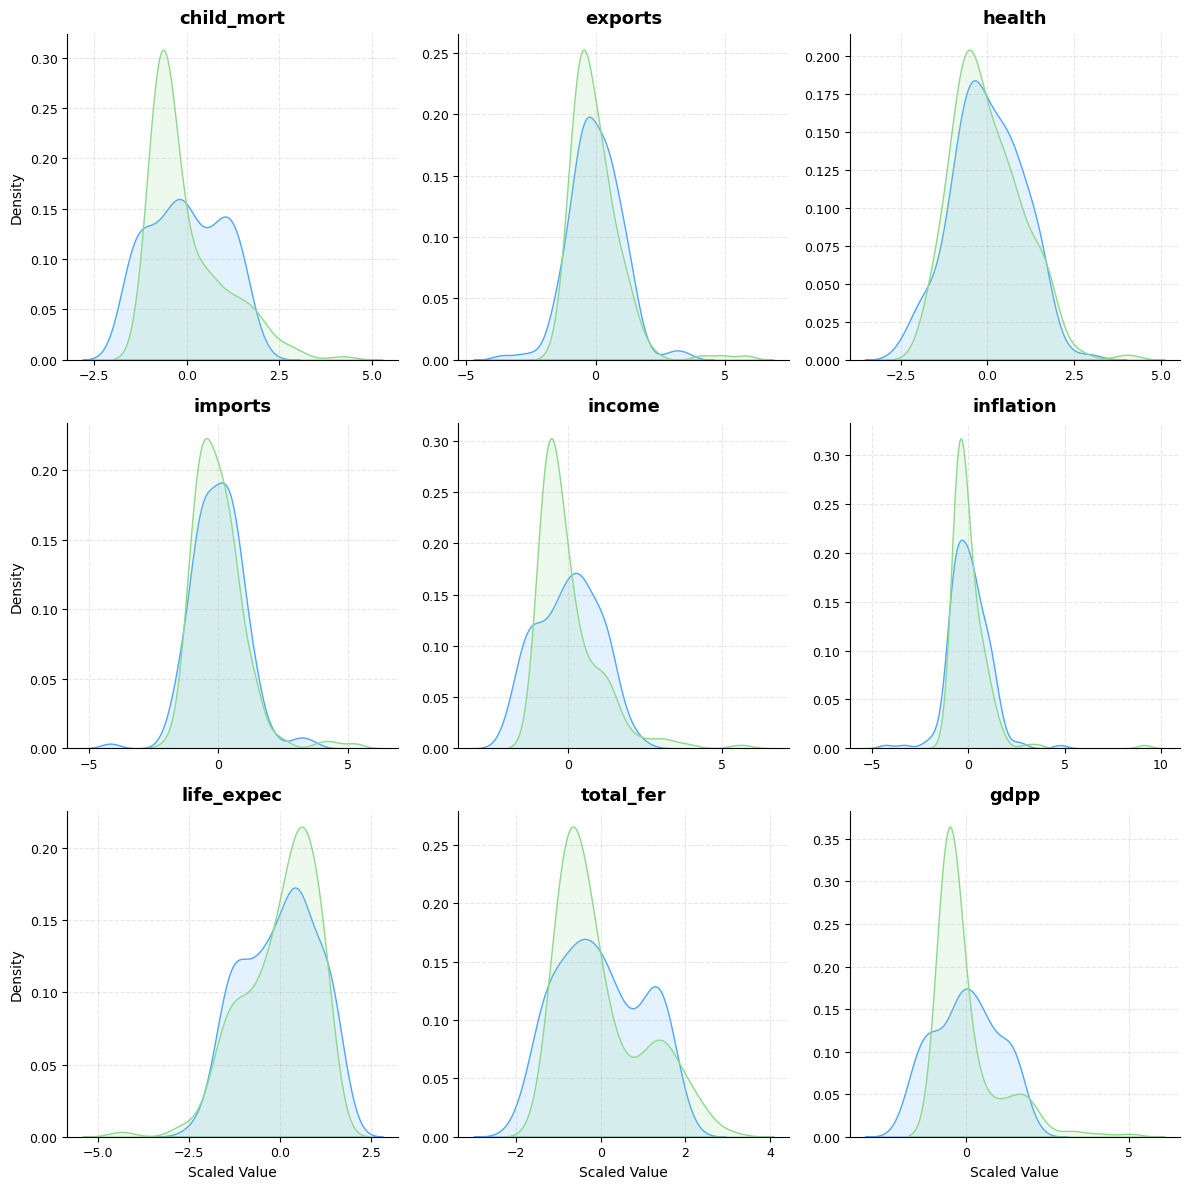

In [22]:
df_std_labeled = df_std.copy().assign(Strategy='Standard Scaling')
df_pwr_labeled = df_pwr.copy().assign(Strategy='Power Transform')
combined_df = pd.concat([df_std_labeled, df_pwr_labeled], axis=0)
plot_compared_boxplots(combined_df, savepath='images/comparison_boxplots.png')
plot_compared_distributions(combined_df, savepath='images/comparison_distributions.png')

## Clustering Analysis

## Bayesian Network